# Part A - Environment Setup

![Screenshot of the set-up environment](Env_Pic.png "Title")

# Part B - MoG Data Creation and Visualization

In [ ]:
import numpy as np

feature_dims=2
components=3
num_samples=1000
means = np.random.uniform(-7,7,size=(components,feature_dims))
covariances = [
    np.diag(np.random.uniform(0.5,1.5,size=feature_dims)) for _ in range(components)
]
np.random.seed(0)

X=[]
y=[]

for i in range(components):
    samples = np.random.multivariate_normal(means[i], covariances[i], size=num_samples//components)
    X.append(samples)
    y.append(np.full((num_samples//components,), i))

X = np.vstack(X)
y = np.hstack(y)

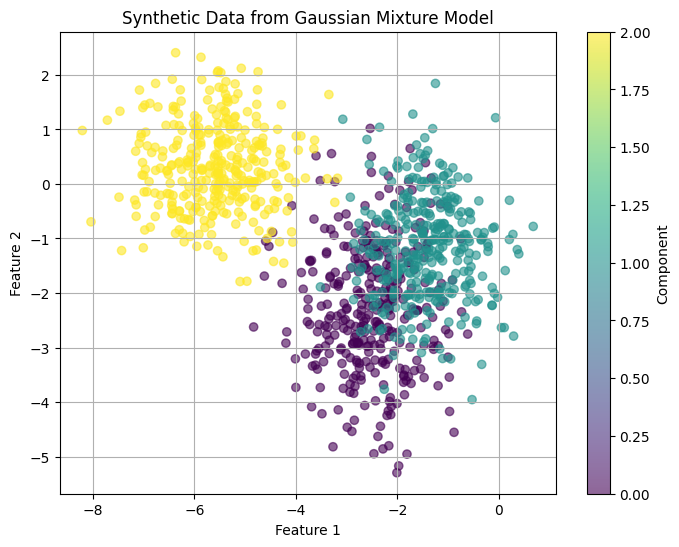

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.6)
plt.title('Synthetic Data from Gaussian Mixture Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Component')
plt.grid()
plt.show()  

# Part C - Gradients Derivation

# Gradient Formulas
**Author:** Shashwat Roy (sr7988@nyu.edu)

---

The likelihood for a point $x_i$ is

$$
p(x_i \mid \pi, \mu, \sigma^2) = \pi_1 \mathcal{N}(x_i \mid \mu_1, \sigma_1^2) + \pi_2 \mathcal{N}(x_i \mid \mu_2, \sigma_2^2).
$$

The log-likelihood for $m$ data points is

$$
\mathcal{L} = \sum_{i=1}^m \log \left( \sum_{k=1}^2 \pi_k \mathcal{N}(x_i \mid \mu_k, \sigma_k^2) \right).
$$

Define the responsibility of component $k$ for data point $i$:

$$
\gamma_{ik} = \frac{\pi_k \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)}{\sum_{j=1}^2 \pi_j \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}.
$$

We also know:

$$
\mathcal{N}(x \mid \mu, \sigma^2) 
= \frac{1}{\sqrt{2\pi \sigma^2}} 
\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

---

## Mean Gradient

$$
\begin{align}
\frac{\partial \mathcal{L}}{\partial \mu_k}
&= \sum_{i=1}^m 
   \frac{1}{\sum_{j=1}^2 \pi_j \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}
   \cdot \frac{\pi_k}{\sqrt{2\pi\sigma_k^2}}
   \exp\!\left(-\frac{(x_i-\mu_k)^2}{2\sigma_k^2}\right)
   \cdot \frac{x_i-\mu_k}{\sigma_k^2} \\[1ex]
&= \sum_{i=1}^m 
   \frac{\pi_k \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)}
        {\sum_{j=1}^2 \pi_j \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}
   \cdot \frac{x_i-\mu_k}{\sigma_k^2} \\[1ex]
&= \sum_{i=1}^m 
   \gamma_{ik} \cdot \frac{x_i-\mu_k}{\sigma_k^2}.
\end{align}
$$

---

## Variance Gradient

$$
\begin{align}
\frac{\partial \mathcal{L}}{\partial \sigma_k^2}
&= \sum_{i=1}^m
   \frac{1}{\sum_{j=1}^2 \pi_j \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}
   \cdot \pi_k \cdot
   \frac{1}{\sqrt{2\pi\sigma_k^2}}
   \exp\!\left(-\frac{(x_i-\mu_k)^2}{2\sigma_k^2}\right)
   \cdot \left(-\frac{1}{2\sigma_k^2} 
   + \frac{(x_i-\mu_k)^2}{2\sigma_k^4}\right) \\[1ex]
\frac{\partial \mathcal{L}}{\partial \sigma_k^2}
&= \sum_{i=1}^m
   \frac{1}{\sum_{j=1}^2 \pi_j \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}
   \cdot \pi_k \cdot
   \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)
   \cdot \left(-\frac{1}{2\sigma_k^2} 
   + \frac{(x_i-\mu_k)^2}{2\sigma_k^4}\right) \\[1ex]
&= \frac{1}{2} \sum_{i=1}^m 
   \gamma_{ik} \left(\frac{(x_i-\mu_k)^2}{\sigma_k^4} 
   - \frac{1}{\sigma_k^2}\right)
\end{align}
$$

---

## Mixture Weights Gradient

$$
\begin{align}
\frac{\partial \mathcal{L}}{\partial \pi_k}
&= \sum_{i=1}^m
   \frac{1}{\sum_{j=1}^2 \pi_j \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}
   \cdot \mathcal{N}(x_i \mid \mu_k,\sigma_k^2) \\[1ex]
&= \sum_{i=1}^m
   \frac{\pi_k\mathcal{N}(x_i \mid \mu_k,\sigma_k^2)}{\sum_{j=1}^2 \pi_j \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}
   \cdot \frac{1}{\pi_k}\\[1ex]
&= \sum_{i=1}^m\frac{\gamma_{ik}}{\pi_k}
\end{align}
$$

# Part D - SGD Implementation

In [ ]:
import numpy as np

def norm_pdf(X, mean, log_var):
    D = X.shape[1]
    var = np.exp(log_var)
    diff = X - mean
    exponent = -0.5 * np.sum((diff ** 2) / var, axis=1)
    log_norm = -0.5 * (D * np.log(2 * np.pi) + np.sum(log_var))
    return np.exp(exponent + log_norm) 

def responsibilities(X, means, log_vars, weights):
    K = len(means)
    N = X.shape[0]
    probs = np.zeros((N, K))
    for k in range(K):
        probs[:, k] = weights[k] * norm_pdf(X, means[k], log_vars[k])

    denom = np.sum(probs, axis=1, keepdims=True) + 1e-10
    return probs / denom 

def mean_gradient(X, resp, k, mean, log_var):
    var = np.exp(log_var)
    diff = X - mean
    grad = np.sum(resp[:, k][:, None] * (diff / var), axis=0)
    return grad

def logvar_gradient(X, resp, k, mean, log_var):
    var = np.exp(log_var)
    diff = X - mean
    grad = 0.5 * np.sum(
        resp[:, k][:, None] * ((diff ** 2) / var - 1),
        axis=0
    )
    return grad

def mw_gradient(resp, weights, k):
    grad = np.sum(resp[:, k]) / (weights[k] + 1e-10)
    return grad

def sgd_step(X, means, log_vars, log_weights, lr=0.01, batch_size=64):

    N = X.shape[0]
    batch_idx = np.random.choice(N, batch_size, replace=False)
    Xb = X[batch_idx]

    exp_w = np.exp(log_weights - np.max(log_weights))
    weights = exp_w / np.sum(exp_w)

    resp = responsibilities(Xb, means, log_vars, weights)

    for k in range(len(means)):
        g_mu = mean_gradient(Xb, resp, k, means[k], log_vars[k])
        g_logvar = logvar_gradient(Xb, resp, k, means[k], log_vars[k])
        g_w = mw_gradient(resp, weights, k)

        means[k] += lr * g_mu
        log_vars[k] += lr * g_logvar
        log_weights[k] += lr * g_w

    return means, log_vars, log_weights

def nll(X, means, log_vars, weights):
    N = X.shape[0]
    K = len(means)
    probs = np.zeros((N, K))
    for k in range(K):
        probs[:, k] = weights[k] * norm_pdf(X, means[k], log_vars[k])
    return -np.sum(np.log(np.sum(probs, axis=1) + 1e-10))


In [ ]:
'''I am using the MoG data from the start of the notebook'''

X = np.vstack(X)
y = np.hstack(y)

log_vars = np.array([np.log(np.diag(cov)) for cov in covariances]) # reparametrization as nmentioned
weights = np.ones(components)/components

lr = 1e-3
epochs = 200

for epoch in range(epochs):
    resp = responsibilities(X, means, log_vars, weights)

    for k in range(components):
        g_mean = mean_gradient(X, resp, k, means[k], log_vars[k])
        g_logvar = logvar_gradient(X, resp, k, means[k], log_vars[k])
        g_weight = mw_gradient(resp, weights, k)

        means[k] += lr*g_mean
        log_vars[k] += lr*g_logvar
        weights[k] += lr*g_weight

    weights = np.maximum(weights, 1e-8)
    weights /= np.sum(weights)

    if (epoch + 1)%20 == 0:
        print(f"Epoch {epoch+1}, NLL = {nll(X, means, log_vars, weights):.2f}")

print("\nUpdated means:\n", means)
print("\nUpdated variances:\n", np.exp(log_vars))
print("\nUpdated weights:\n", weights)


Epoch 20, NLL = 3377.40
Epoch 40, NLL = 3349.60
Epoch 60, NLL = 3343.82
Epoch 80, NLL = 3343.21
Epoch 100, NLL = 3343.15
Epoch 120, NLL = 3343.14
Epoch 140, NLL = 3343.14
Epoch 160, NLL = 3343.14
Epoch 180, NLL = 3343.14
Epoch 200, NLL = 3343.14

Updated means:
 [[-1.43633096 -1.11472818]
 [-2.48817539 -2.36467661]
 [-5.57263836  0.30261305]]

Updated variances:
 [[0.52823103 0.86004471]
 [0.57138466 1.17241143]
 [0.75322089 0.65086503]]

Updated weights:
 [0.33479404 0.33005446 0.3351515 ]
